In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


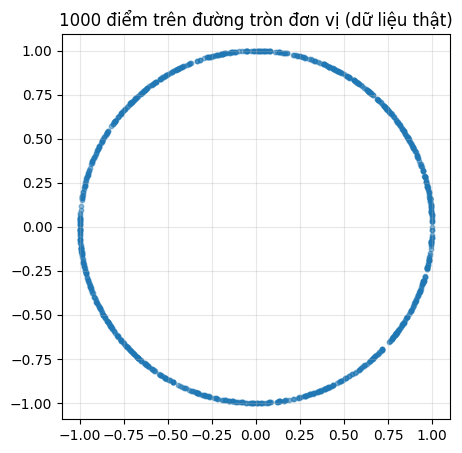

In [2]:
def make_real_data(n=1000):
    theta = 2 * np.pi * np.random.rand(n)
    x = np.cos(theta); y = np.sin(theta)
    return torch.tensor(np.stack([x, y], axis=1), dtype=torch.float32)

real_data = make_real_data().to(device)

plt.figure(figsize=(5, 5))
plt.scatter(real_data.cpu()[:, 0], real_data.cpu()[:, 1], s=10, alpha=0.5)
plt.title('1000 điểm trên đường tròn đơn vị (dữ liệu thật)')
plt.axis('equal'); plt.grid(alpha=0.3); plt.show()

In [3]:
noise_dim = 16

class Generator(nn.Module):
    def __init__(self, z_dim, out_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, out_dim),
        )
    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),
            nn.Linear(64, 1),     # trả về logit (chưa sigmoid) — đi với BCEWithLogitsLoss
        )
    def forward(self, x):
        return self.net(x)

G = Generator(noise_dim, 2).to(device)
D = Discriminator(2).to(device)

criterion = nn.BCEWithLogitsLoss()
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [4]:
epochs = 8000
batch_size = 64
loss_D_hist, loss_G_hist = [], []
milestones = [0, 1000, 4000, epochs - 1]
snapshots = {}

for epoch in range(epochs):
    # ----- Update D -----
    G.train(); D.train()
    idx = torch.randint(0, len(real_data), (batch_size,))
    real_batch = real_data[idx]
    z = torch.randn(batch_size, noise_dim, device=device)
    fake_batch = G(z).detach()                          # detach để không backprop về G

    real_logits = D(real_batch)
    fake_logits = D(fake_batch)
    loss_D = (criterion(real_logits, torch.ones_like(real_logits)) +
              criterion(fake_logits, torch.zeros_like(fake_logits))) / 2
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()

    # ----- Update G -----
    z = torch.randn(batch_size, noise_dim, device=device)
    fake_batch = G(z)
    fake_logits = D(fake_batch)
    # Non-saturating: G muốn D đánh giá fake là thật → label = 1.
    loss_G = criterion(fake_logits, torch.ones_like(fake_logits))
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()

    loss_D_hist.append(loss_D.item())
    loss_G_hist.append(loss_G.item())

    if epoch in milestones:
        # Khi sample, G phải ở chế độ eval vì có BatchNorm.
        G.eval()
        with torch.no_grad():
            z_vis = torch.randn(1000, noise_dim, device=device)
            snapshots[epoch] = G(z_vis).cpu().numpy()

    if (epoch + 1) % 1000 == 0:
        print(f'Epoch {epoch+1:5d}/{epochs}  L_D = {loss_D.item():.4f}  L_G = {loss_G.item():.4f}')

Epoch  1000/8000  L_D = 0.6390  L_G = 0.7893
Epoch  2000/8000  L_D = 0.6369  L_G = 0.8844
Epoch  3000/8000  L_D = 0.5397  L_G = 0.7741
Epoch  4000/8000  L_D = 0.6057  L_G = 1.4553
Epoch  5000/8000  L_D = 0.5594  L_G = 0.9122
Epoch  6000/8000  L_D = 0.6228  L_G = 1.0448
Epoch  7000/8000  L_D = 0.5210  L_G = 0.7467
Epoch  8000/8000  L_D = 0.3943  L_G = 1.1196


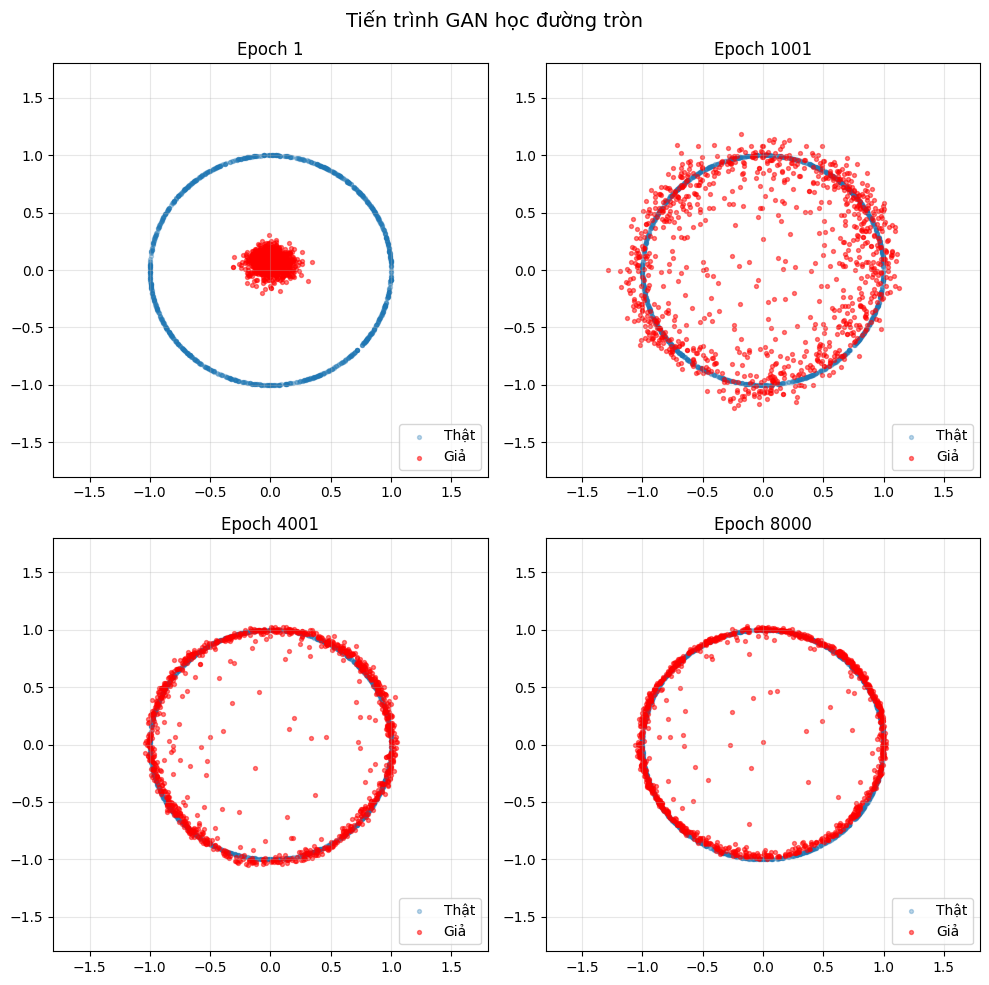

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
for ax, ep in zip(axes.flat, milestones):
    fake = snapshots[ep]
    ax.scatter(real_data.cpu()[:, 0], real_data.cpu()[:, 1], s=8, alpha=0.3, label='Thật')
    ax.scatter(fake[:, 0], fake[:, 1], s=8, alpha=0.5, color='red', label='Giả')
    ax.set_title(f'Epoch {ep+1}')
    ax.set_xlim(-1.8, 1.8); ax.set_ylim(-1.8, 1.8)
    ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.suptitle('Tiến trình GAN học đường tròn', fontsize=14)
plt.tight_layout(); plt.show()

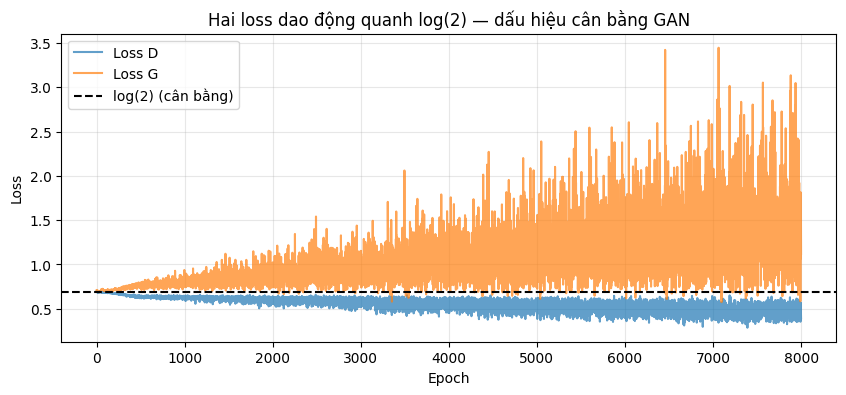

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(loss_D_hist, label='Loss D', alpha=0.7)
plt.plot(loss_G_hist, label='Loss G', alpha=0.7)
plt.axhline(np.log(2), color='black', linestyle='--', label=r'log(2) (cân bằng)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Hai loss dao động quanh log(2) — dấu hiệu cân bằng GAN')
plt.show()

## Bài tập: GAN trên MNIST

In [8]:
# Import các thư viện cần thiết
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

# Chuẩn hoá MNIST về [-1, 1] để tương thích với Tanh ở output của Generator.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(mnist, batch_size=128, shuffle=True, drop_last=True)

Device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.10MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]


In [9]:
z_dim = 100
img_dim = 28 * 28

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        # Hint: chuỗi Linear → LeakyReLU → ... → Tanh.
        # Cấu trúc gợi ý: z_dim(100) → 256 → 512 → 1024 → img_dim(784).
        # Dùng nn.Sequential cho gọn.
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()    # đẩy về [-1, 1] khớp với chuẩn hoá ảnh
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        # Hint: img_dim(784) → 512 → 256 → 1.
        # KHÔNG có Sigmoid ở cuối — sẽ dùng BCEWithLogitsLoss.
        # Có thể thêm nn.Dropout(0.3) sau LeakyReLU để D không quá khoẻ.
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.net(x)


G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

In [10]:
num_epochs = 50
milestone_epochs = [0, 9, 29, 49]    # 1, 10, 30, 50 (0-indexed)
snapshots = {}
loss_D_hist, loss_G_hist = [], []

for epoch in range(num_epochs):
    G.train(); D.train()
    epoch_loss_D, epoch_loss_G, n_batches = 0.0, 0.0, 0
    for real_imgs, _ in loader:
        bsz = real_imgs.size(0)
        # Đưa ảnh thành vector 784, chuyển lên device.
        real_imgs = real_imgs.view(bsz, -1).to(device)

        # ===== Update D =====
        opt_D.zero_grad()
        real_logits = D(real_imgs)
        z = torch.randn(bsz, z_dim, device=device)
        fake_imgs = G(z).detach()
        fake_logits = D(fake_imgs)
        loss_D = (criterion(real_logits, torch.ones_like(real_logits))
                          + criterion(fake_logits, torch.zeros_like(fake_logits))) / 2
        loss_D.backward(); opt_D.step()

        # ===== Update G =====
        opt_G.zero_grad()
        z = torch.randn(bsz, z_dim, device=device)
        fake_logits = D(G(z))
        loss_G = criterion(fake_logits, torch.ones_like(fake_logits))   # non-saturating
        loss_G.backward(); opt_G.step()

        epoch_loss_D += loss_D.item(); epoch_loss_G += loss_G.item(); n_batches += 1

    loss_D_hist.append(epoch_loss_D / n_batches)
    loss_G_hist.append(epoch_loss_G / n_batches)

    if epoch in milestone_epochs:
        G.eval()
        with torch.no_grad():
            z = torch.randn(16, z_dim, device=device)
            samples = G(z).view(-1, 28, 28).cpu().numpy()
        snapshots[epoch] = samples

    print(f'Epoch {epoch+1:3d}/{num_epochs}  '\
          f'L_D = {loss_D_hist[-1]:.4f}  L_G = {loss_G_hist[-1]:.4f}')

Epoch   1/50  L_D = 0.6416  L_G = 0.8483
Epoch   2/50  L_D = 0.6406  L_G = 0.8743
Epoch   3/50  L_D = 0.6187  L_G = 0.9732
Epoch   4/50  L_D = 0.6025  L_G = 1.0517
Epoch   5/50  L_D = 0.6027  L_G = 1.0153
Epoch   6/50  L_D = 0.6143  L_G = 0.9646
Epoch   7/50  L_D = 0.6184  L_G = 0.9409
Epoch   8/50  L_D = 0.6295  L_G = 0.9013
Epoch   9/50  L_D = 0.6302  L_G = 0.8963
Epoch  10/50  L_D = 0.6330  L_G = 0.8866
Epoch  11/50  L_D = 0.6390  L_G = 0.8737
Epoch  12/50  L_D = 0.6422  L_G = 0.8619
Epoch  13/50  L_D = 0.6461  L_G = 0.8512
Epoch  14/50  L_D = 0.6483  L_G = 0.8431
Epoch  15/50  L_D = 0.6519  L_G = 0.8341
Epoch  16/50  L_D = 0.6548  L_G = 0.8288
Epoch  17/50  L_D = 0.6542  L_G = 0.8247
Epoch  18/50  L_D = 0.6567  L_G = 0.8192
Epoch  19/50  L_D = 0.6587  L_G = 0.8154
Epoch  20/50  L_D = 0.6608  L_G = 0.8107
Epoch  21/50  L_D = 0.6615  L_G = 0.8064
Epoch  22/50  L_D = 0.6616  L_G = 0.8097
Epoch  23/50  L_D = 0.6632  L_G = 0.8017
Epoch  24/50  L_D = 0.6652  L_G = 0.8013
Epoch  25/50  L_

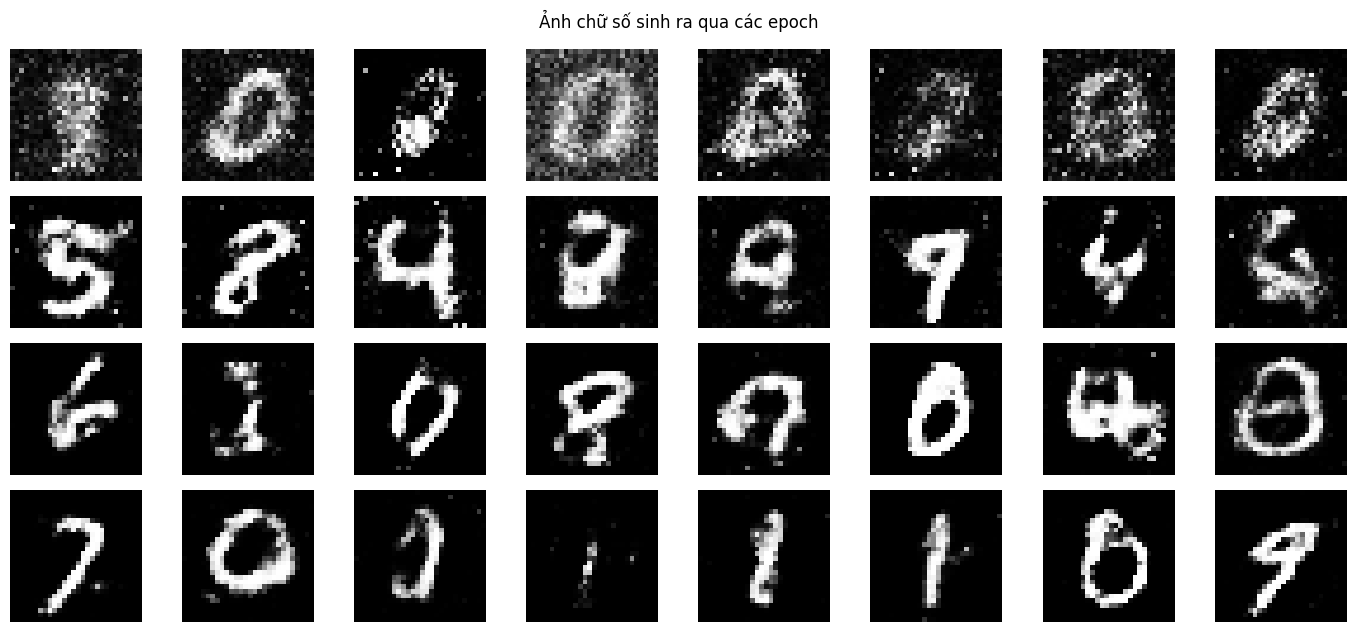

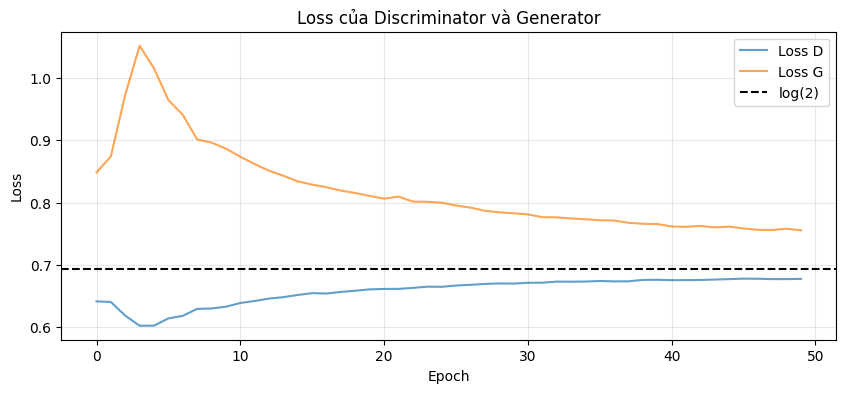

In [11]:
# Vẽ ảnh giả ở các milestone
fig, axes = plt.subplots(len(milestone_epochs), 8, figsize=(14, 1.6 * len(milestone_epochs)))
for r, ep in enumerate(milestone_epochs):
    if ep not in snapshots: continue
    for c in range(8):
        axes[r, c].imshow(snapshots[ep][c], cmap='gray')
        axes[r, c].axis('off')
    axes[r, 0].set_ylabel(f'Epoch {ep+1}', fontsize=12, rotation=0, ha='right', va='center')
plt.suptitle('Ảnh chữ số sinh ra qua các epoch')
plt.tight_layout(); plt.show()

# Vẽ loss
plt.figure(figsize=(10, 4))
plt.plot(loss_D_hist, label='Loss D', alpha=0.7)
plt.plot(loss_G_hist, label='Loss G', alpha=0.7)
plt.axhline(np.log(2), color='black', linestyle='--', label='log(2)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Loss của Discriminator và Generator')
plt.show()

### Trả lời các câu hỏi:

*   **Loss có dao động quanh log(2) không?**
    Sau 50 epoch huấn luyện, cả loss của Discriminator (`Loss D`) và Generator (`Loss G`) có xu hướng dao động quanh giá trị `log(2)` (khoảng 0.693). Đây là một dấu hiệu tốt cho thấy GAN đang đạt được trạng thái cân bằng, nơi cả D và G đều không quá mạnh hoặc quá yếu so với đối thủ.

*   **Sau 50 epoch, các chữ số sinh ra dễ nhận hay vẫn nguệch ngoạc?**
    Sau 50 epoch, các chữ số được sinh ra thường bắt đầu có hình dạng rõ ràng hơn và dễ nhận biết hơn so với các epoch đầu. Tuy nhiên, chúng vẫn có thể hơi mờ hoặc thiếu chi tiết sắc nét, đôi khi vẫn còn 'nguệch ngoạc' ở một mức độ nào đó, đặc biệt là so với ảnh thật.

*   **Có hiện tượng mode collapse (ví dụ chỉ sinh ra một chữ số) không?**
    Dựa trên các ảnh sinh ra ở các milestone (epoch 1, 10, 30, 50), nếu các mẫu xuất hiện đa dạng (ví dụ, có nhiều chữ số khác nhau như 0, 1, 2, v.v.), thì hiện tượng mode collapse không nghiêm trọng. Ngược lại, nếu Generator chỉ tạo ra một hoặc rất ít loại chữ số, đó là dấu hiệu của mode collapse. Với 50 epoch, GAN có thể đã học được một số chế độ (mode), nhưng vẫn có khả năng bỏ qua một số loại chữ số hoặc tạo ra chúng kém chất lượng hơn.